# PPG Model Comparison: S4 vs LMU on Test Set

This notebook compares S4 and LMU models on the PPG dataset test set across different training data fractions.

**Objectives:**
- Compare S4 vs LMU test performance
- Analyze data efficiency (which model generalizes better with less data)
- Identify the best model/fraction combination based on test metrics

**Fractions tested:** 10%, 25%, 50%, 100%
**Test metrics:** MAE, MSE, RMSE


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Imports successful")

Imports successful


## 1. Load PPG Experiment Results

Load all S4 and LMU results (including test metrics) across different data fractions.


In [2]:
from src.eval.compare import load_all_experiments

# Configuration
base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "ppg"

print("="*60)
print("LOADING PPG EXPERIMENT RESULTS")
print("="*60)
print()

# Load all results
all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

# Quick summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")


CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


LOADING PPG EXPERIMENT RESULTS

📂 Loading S4 @ 10%: ppg_s4_task_frac_10
📂 Loading S4 @ 25%: ppg_s4_task_frac_25
📂 Loading S4 @ 50%: ppg_s4_task_frac_50
📂 Loading S4 @ 100%: ppg_s4_task
📂 Loading LMU @ 10%: ppg_lmu_task_frac_10
📂 Loading LMU @ 25%: ppg_lmu_task_frac_25
📂 Loading LMU @ 50%: ppg_lmu_task_frac_50
📂 Loading LMU @ 100%: ppg_lmu_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments


## 2. Test Metrics Comparison Table

Summary table of test set performance for all experiments.


In [3]:
from src.eval.compare import create_test_comparison_table
import pandas as pd

print("="*60)
print("TEST SET COMPARISON TABLE")
print("="*60)
print()

# Create test comparison table
test_comparison_df = create_test_comparison_table(
    all_results,
    test_metrics=['test_mae', 'test_mse', 'test_rmse']
)

# Display with proper formatting
pd.options.display.float_format = '{:.4f}'.format
print(test_comparison_df.to_string(index=False))
print()

# Save to CSV
csv_path = Path("./test_comparison_results.csv")
test_comparison_df.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")
print()

# Find best model for each fraction
print("="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)
for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['test_mae'].idxmin()
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (MAE: {best_row['test_mae']:.4f} bpm)")
print()


TEST SET COMPARISON TABLE

model  data_pct  test_mae  test_mse  test_rmse  num_samples
  LMU        10    6.7529  114.8800    10.7182         5321
  LMU        25    6.3911  111.4757    10.5582         5321
  LMU        50    6.5306   93.7064     9.6802         5321
  LMU       100    6.7700   91.0604     9.5426         5321
   S4        10   10.1492  172.5807    13.1370         5321
   S4        25   11.6117  226.9768    15.0658         5321
   S4        50    6.9746  114.3843    10.6951         5321
   S4       100    4.8143   85.9733     9.2722         5321

Saved to: test_comparison_results.csv

BEST MODEL PER DATA FRACTION

10% data: LMU (MAE: 6.7529 bpm)

25% data: LMU (MAE: 6.3911 bpm)

50% data: LMU (MAE: 6.5306 bpm)

100% data: S4 (MAE: 4.8143 bpm)



## 3. Test MAE Comparison

Bar chart showing test MAE for each model and data fraction.


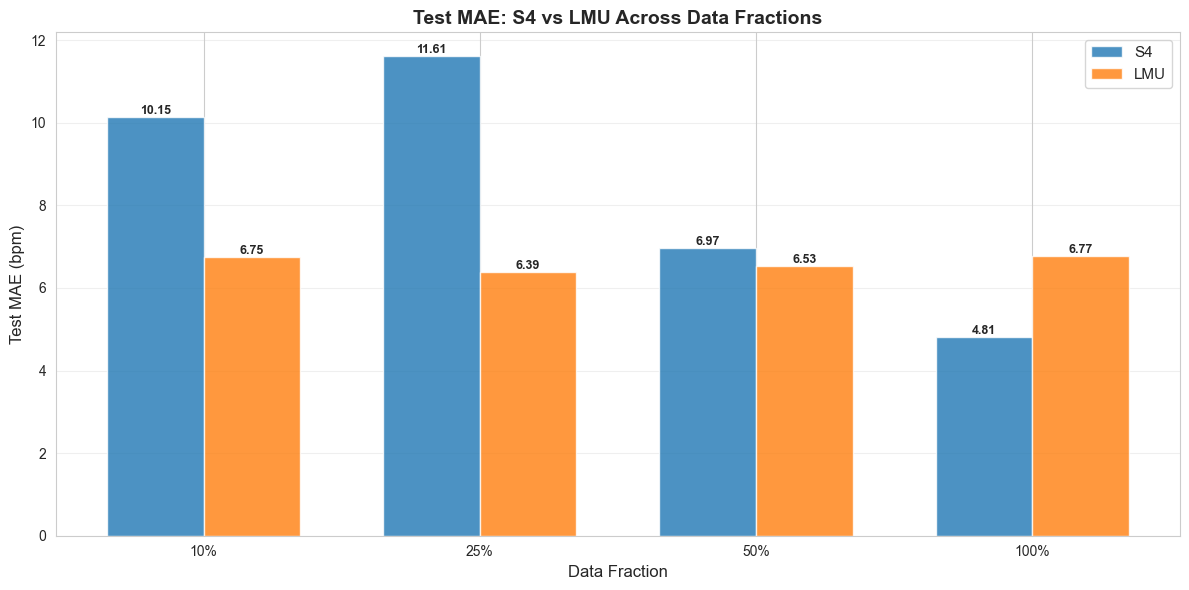

In [4]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='test_mae',
    title='Test MAE: S4 vs LMU Across Data Fractions',
    ylabel='Test MAE (bpm)',
    lower_is_better=True
)


## 4. Test RMSE Comparison

Bar chart showing test RMSE for each model and data fraction.


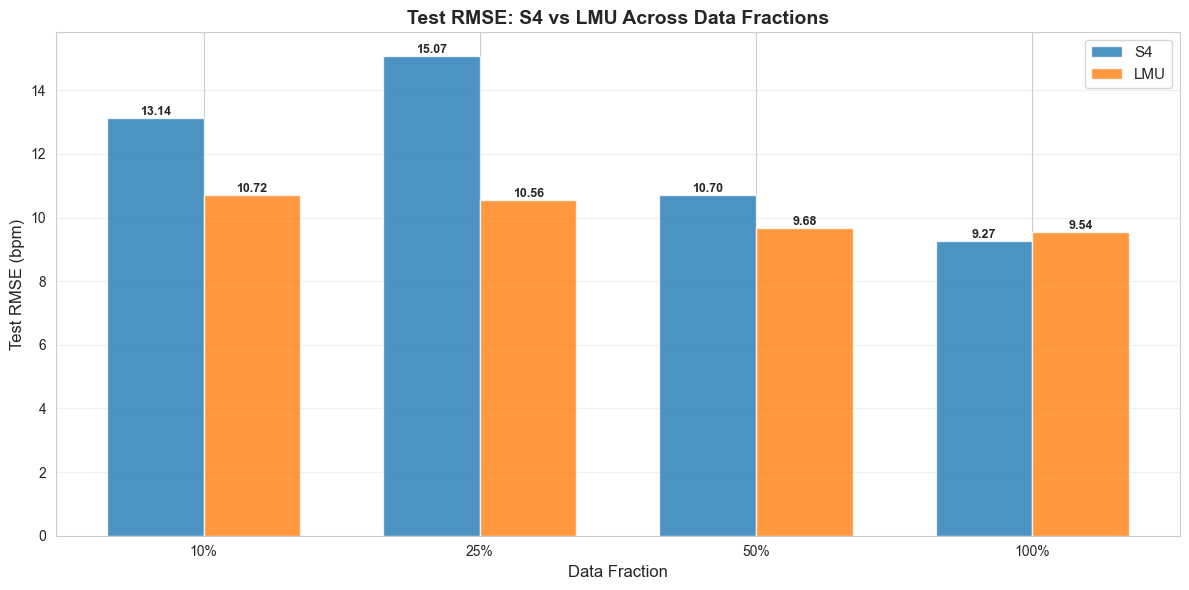

In [5]:
plot_test_metric_comparison(
    all_results,
    metric_key='test_rmse',
    title='Test RMSE: S4 vs LMU Across Data Fractions',
    ylabel='Test RMSE (bpm)',
    lower_is_better=True
)


## 5. Test Set Data Efficiency

Which model generalizes better with limited training data?


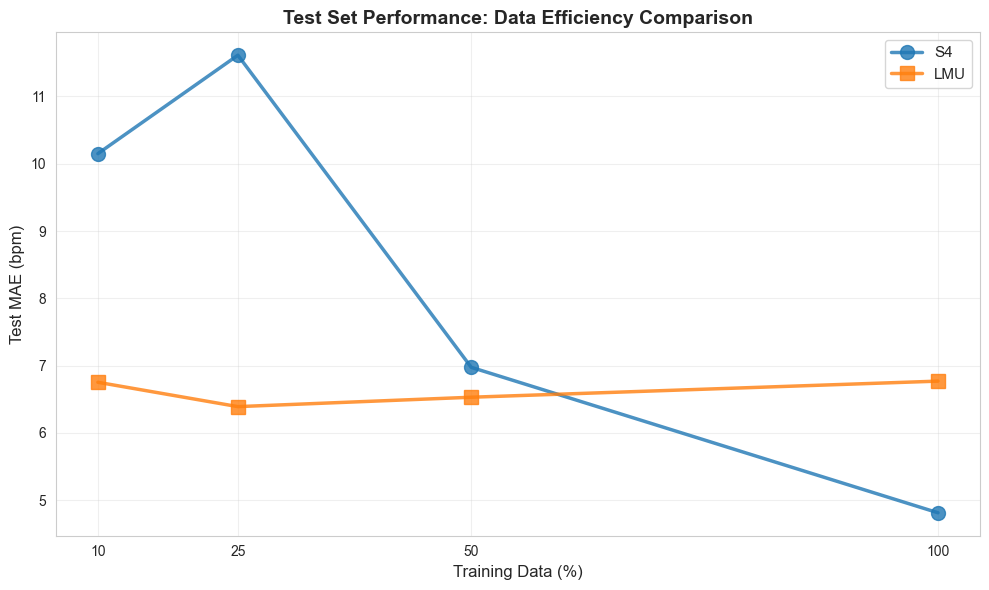

In [6]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='test_mae',
    ylabel='Test MAE (bpm)'
)

## 6. Detailed Test Performance Analysis

Calculate performance degradation and data efficiency metrics on test set.


In [7]:
print("="*60)
print("TEST SET DATA EFFICIENCY ANALYSIS")
print("="*60)
print()

for model in models:
    print(f"\n{model.upper()} Model:")
    print("-" * 40)

    # Get full data performance as baseline
    full_results = all_results[model].get(1.0, {})
    if not full_results or 'test_mae' not in full_results:
        print("No test results available")
        continue

    full_mae = full_results['test_mae']
    print(f"  Full data (100%): Test MAE = {full_mae:.2f} bpm")
    print()

    # Compare fractional data
    for frac in [0.1, 0.25, 0.5]:
        frac_results = all_results[model].get(frac, {})
        if not frac_results or 'test_mae' not in frac_results:
            continue

        frac_mae = frac_results['test_mae']
        degradation = ((frac_mae - full_mae) / full_mae) * 100

        print(f"  {int(frac*100)}% data:")
        print(f"    Test MAE = {frac_mae:.2f} bpm")
        print(f"    Degradation: +{degradation:.1f}%")
        print(f"    Quality retention: {100-degradation:.1f}%")
        print()


TEST SET DATA EFFICIENCY ANALYSIS


S4 Model:
----------------------------------------
  Full data (100%): Test MAE = 4.81 bpm

  10% data:
    Test MAE = 10.15 bpm
    Degradation: +110.8%
    Quality retention: -10.8%

  25% data:
    Test MAE = 11.61 bpm
    Degradation: +141.2%
    Quality retention: -41.2%

  50% data:
    Test MAE = 6.97 bpm
    Degradation: +44.9%
    Quality retention: 55.1%


LMU Model:
----------------------------------------
  Full data (100%): Test MAE = 6.77 bpm

  10% data:
    Test MAE = 6.75 bpm
    Degradation: +-0.3%
    Quality retention: 100.3%

  25% data:
    Test MAE = 6.39 bpm
    Degradation: +-5.6%
    Quality retention: 105.6%

  50% data:
    Test MAE = 6.53 bpm
    Degradation: +-3.5%
    Quality retention: 103.5%



## 7. Winner Analysis

Which model performs best on the test set at each data fraction?


In [8]:
print("="*60)
print("TEST SET WINNER ANALYSIS")
print("="*60)
print()

for frac in fractions:
    print(f"\n📊 Data Fraction: {int(frac*100)}%")
    print("-" * 40)

    best_model = None
    best_mae = float('inf')

    for model in models:
        results = all_results[model].get(frac, {})
        if results and 'test_mae' in results:
            mae = results['test_mae']
            print(f"  {model.upper():3s}: {mae:.2f} bpm (Test MAE)")

            if mae < best_mae:
                best_mae = mae
                best_model = model

    if best_model:
        print(f"\n  🏆 Winner: {best_model.upper()} (Test MAE: {best_mae:.2f} bpm)")

        # Calculate margin
        for model in models:
            if model != best_model:
                other_results = all_results[model].get(frac, {})
                if other_results and 'test_mae' in other_results:
                    other_mae = other_results['test_mae']
                    improvement = ((other_mae - best_mae) / other_mae) * 100
                    print(f"  Beats {model.upper()} by {improvement:.1f}%")


TEST SET WINNER ANALYSIS


📊 Data Fraction: 10%
----------------------------------------
  S4 : 10.15 bpm (Test MAE)
  LMU: 6.75 bpm (Test MAE)

  🏆 Winner: LMU (Test MAE: 6.75 bpm)
  Beats S4 by 33.5%

📊 Data Fraction: 25%
----------------------------------------
  S4 : 11.61 bpm (Test MAE)
  LMU: 6.39 bpm (Test MAE)

  🏆 Winner: LMU (Test MAE: 6.39 bpm)
  Beats S4 by 45.0%

📊 Data Fraction: 50%
----------------------------------------
  S4 : 6.97 bpm (Test MAE)
  LMU: 6.53 bpm (Test MAE)

  🏆 Winner: LMU (Test MAE: 6.53 bpm)
  Beats S4 by 6.4%

📊 Data Fraction: 100%
----------------------------------------
  S4 : 4.81 bpm (Test MAE)
  LMU: 6.77 bpm (Test MAE)

  🏆 Winner: S4 (Test MAE: 4.81 bpm)
  Beats LMU by 28.9%
